## Extended Analysis on Model Performance and Data Embeddings & Labels ##

In [1]:
import os, sys
from pathlib import Path

# Anchor on the project root so relative paths ('results/...', 'checkpoints/...')
# resolve regardless of where Jupyter was launched. src/ is added to sys.path
# so model.py / dataset.py imports work.
PROJECT_ROOT = Path('/home/buthaina.almulla/Documents/CV7502')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from PIL import Image
from sklearn.manifold import TSNE
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
from model import Embeddinghead
from dataset import DroneFaceDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
backbone = InceptionResnetV1(pretrained='vggface2').to(device)
head = Embeddinghead(input_dim=512, Embedding_dim=256).to(device)
ckpt = torch.load('checkpoints/checkpoints/best_drone_model_v2.pth', map_location=device)
backbone.load_state_dict(ckpt['backbone'])
head.load_state_dict(ckpt['head'])
backbone.eval(); head.eval()

os.makedirs('results/analysis', exist_ok=True)
print('Setup complete.')

/home/buthaina.almulla/Documents/CV7502/venv/lib/python3.10/site-packages/facenet_pytorch/models/inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  st

Setup complete.


/tmp/slurm-buthaina.almulla-132196/ipykernel_2850432/3554600463.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/checkpoints/best_drone_mo


## t-SNE Embedding Visualisation
Shows how identities cluster in 256-d embedding space after two-phase training.

In [2]:
#Loading the raw saved embeddings for training and validation
train_embeddings = np.load('results/cache/cache_train_embeddings.npy')
validation_embeddings = np.load('results/cache/cache_validation_embeddings.npy')
train_labels = np.load('results/cache/cache_train_labels.npy')
validation_labels = np.load('results/cache/cache_validation_labels.npy')

# Remaping validation identity label 0 → 8 (identity I, distinct from train identity A)
validation_labels_remapped = validation_labels + 8
baseline_embeddings = np.concatenate([train_embeddings, validation_embeddings], axis=0)
baseline_labels = np.concatenate([train_labels, validation_labels_remapped], axis=0)

# Loading saved embeddings after two-phase training
embeddings = np.load('results/embeddings/two_phase_droneface.npy')
labels = np.load('results/embeddings/two_phase_droneface_labels.npy')

print(f'Embeddings: {embeddings.shape}  |  Unique identities: {len(set(labels))}')

Embeddings: (1364, 256)  |  Unique identities: 11


In [3]:
from sklearn import __version__ as sk_version
#T_SNE method: 
def tsne(embs):
    tsne_kwargs = {
        "n_components":2,
        "perplexity": min(30, len(embs) // 4),   # auto-adjust for small datasets
        'random_state':42,
        'verbose':1
    }

    if tuple(int(x) for x in sk_version.split(".")[:2]) >= (1,5):
        tsne_kwargs["max_iter"] = 1000
    else: 
        tsne_kwargs["n_iter"] = 1000
    return TSNE(**tsne_kwargs).fit_transform(embs)

baseline_tsne = tsne(baseline_embeddings)
twophase_tsne = tsne(embeddings)
print('t-SNE done.')

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1175 samples in 0.001s...


[t-SNE] Computed neighbors for 1175 samples in 0.201s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1175
[t-SNE] Computed conditional probabilities for sample 1175 / 1175
[t-SNE] Mean sigma: 0.279366


[t-SNE] KL divergence after 250 iterations with early exaggeration: 59.266468


[t-SNE] KL divergence after 1000 iterations: 0.552811
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1364 samples in 0.000s...
[t-SNE] Computed neighbors for 1364 samples in 0.023s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1364
[t-SNE] Computed conditional probabilities for sample 1364 / 1364
[t-SNE] Mean sigma: 0.273298


[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.689812


[t-SNE] KL divergence after 1000 iterations: 0.746454
t-SNE done.


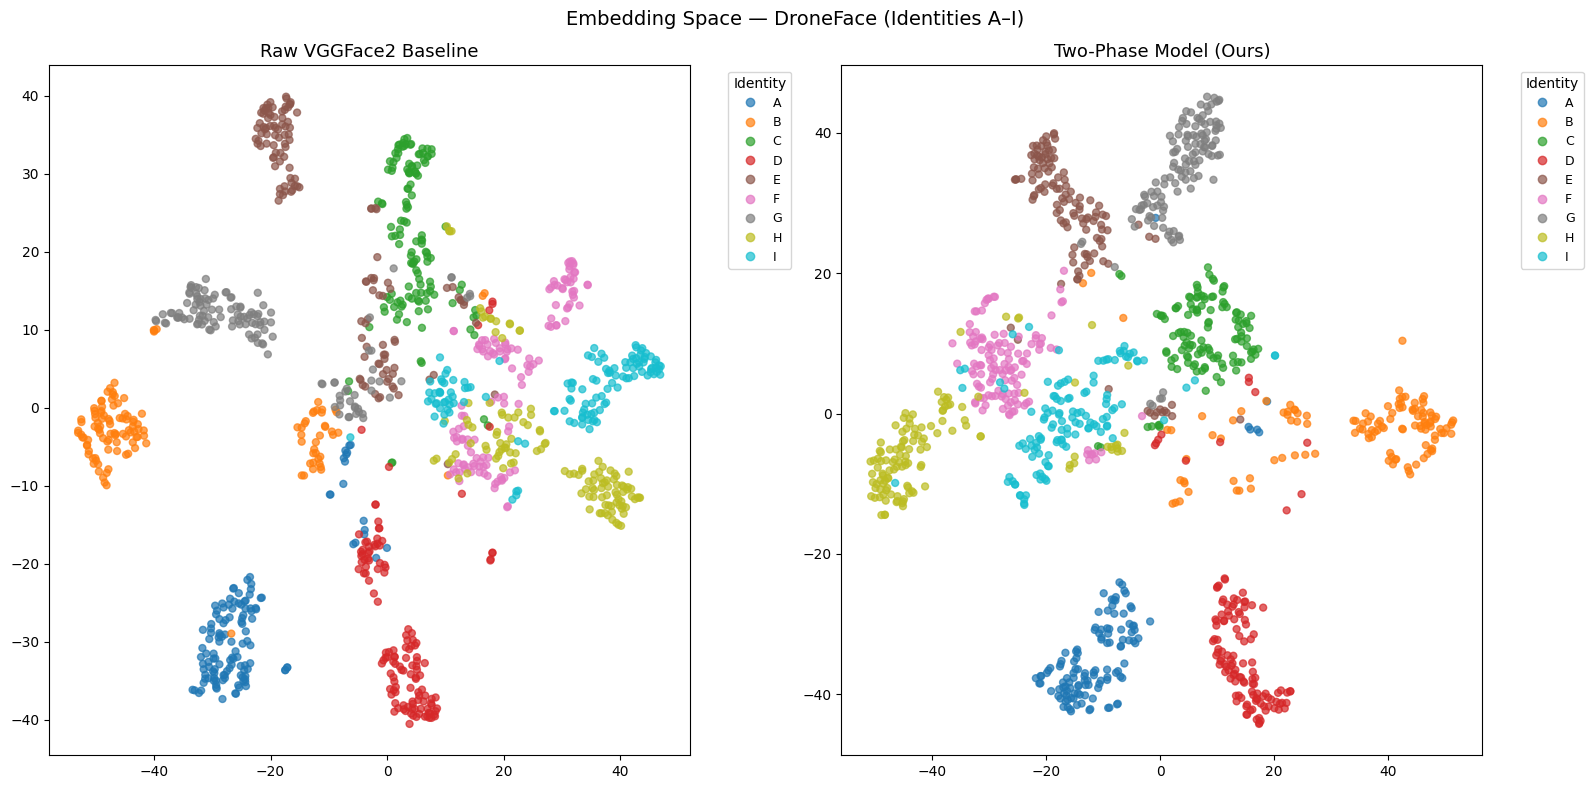

In [4]:
# Plot side-by-side t-SNE visualizations for baseline vs two-phase model
LABEL_MAP = {'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6,'H':7,'I':8}

# convert two-phase string labels to int, drop J/K
mask = np.array([l in LABEL_MAP for l in labels])
tp_proj = twophase_tsne[mask]
tp_labels = np.array([LABEL_MAP[l] for l in labels[mask]])

cmap = plt.colormaps['tab10']
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, proj, lbl, title in zip(
    axes,
    [baseline_tsne, tp_proj],
    [baseline_labels, tp_labels],
    ['Raw VGGFace2 Baseline', 'Two-Phase Model (Ours)']
):
    scatter = ax.scatter(proj[:, 0], proj[:, 1], c=lbl, cmap='tab10', s=25, alpha=0.7)
    ax.set_title(title, fontsize=13)
    handles, _ = scatter.legend_elements()
    ax.legend(handles, ['A','B','C','D','E','F','G','H','I'], 
          title='Identity', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.suptitle('Embedding Space — DroneFace (Identities A–I)', fontsize=14)
plt.tight_layout()
plt.savefig('results/analysis/tsne_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Confusion Matrix and ROC Data Visualization

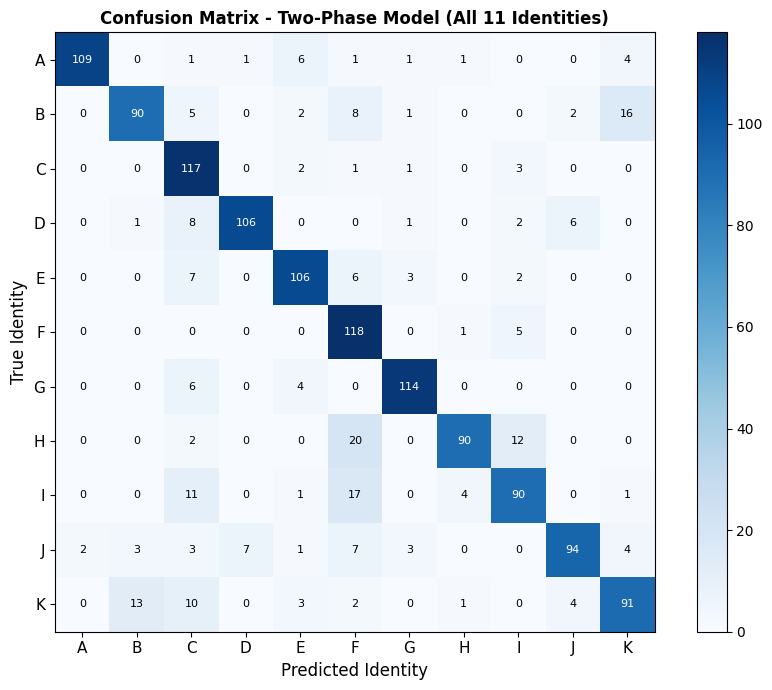

Confusion matrix saved.
Micro-AUC: 0.8857


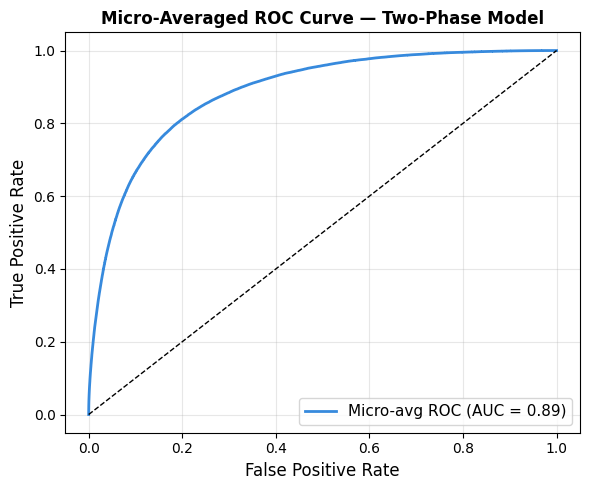

ROC curve saved. AUC = 0.8857


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Loading the confusion matrix (regenerated by scripts/run_ablation_eval.py
# from the headline both_phases_original checkpoint best_drone_model_v2.pth).
confusion_matrix = np.load('results/confusion_matrix.npy')
id_names = ['A','B','C','D','E','F','G','H','I','J','K']

# Plotting the confusion matrix
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(confusion_matrix, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(11))
ax.set_yticks(range(11))
ax.set_xticklabels(id_names, fontsize=11)
ax.set_yticklabels(id_names, fontsize=11)
ax.set_xlabel('Predicted Identity', fontsize=12)
ax.set_ylabel('True Identity', fontsize=12)
ax.set_title('Confusion Matrix - Two-Phase Model (All 11 Identities)',
             fontsize=12, fontweight='bold')

for i in range(11):
    for j in range(11):
        validation = confusion_matrix[i, j]
        color = 'white' if validation > confusion_matrix.max() / 2 else 'black'
        ax.text(j, i, str(validation), ha='center', va='center',
                fontsize=8, color=color)

plt.tight_layout()
plt.savefig('results/analysis/confusion_matrix_full.png', dpi=200, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

# ROC: build pairwise (same/different identity) labels and cosine-similarity scores
# from the saved two-phase embeddings, instead of relying on a stale roc_data.npy.
import torch
import torch.nn.functional as F

emb_t = torch.from_numpy(embeddings).float()
emb_norm = F.normalize(emb_t, p=2, dim=1)
sim_mat = (emb_norm @ emb_norm.T).numpy()

# upper triangle (i<j) gives all unique pairs without self-pairs
iu = np.triu_indices(len(labels), k=1)
y_true = (labels[iu[0]] == labels[iu[1]]).astype(np.int32)
y_score = sim_mat[iu]

# persist for any downstream tooling that expects results/roc_data.npy
np.save('results/roc_data.npy', np.array([y_true, y_score]))

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
print(f'Micro-AUC: {roc_auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#378ADD', lw=2,
        label=f'Micro-avg ROC (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Micro-Averaged ROC Curve — Two-Phase Model',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/analysis/roc_curve_full.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'ROC curve saved. AUC = {roc_auc:.4f}')

## Per-Identity Accuracy and Error Rate & Worst Failure Cases ##


Identity  Accuracy (%)  Error Rate (%)  Total Samples
       A         87.90           12.10            124
       B         72.58           27.42            124
       C         94.35            5.65            124
       D         85.48           14.52            124
       E         85.48           14.52            124
       F         95.16            4.84            124
       G         91.94            8.06            124
       H         72.58           27.42            124
       I         72.58           27.42            124
       J         75.81           24.19            124
       K         73.39           26.61            124

Overall Rank-1 (from confusion matrix): 82.48%


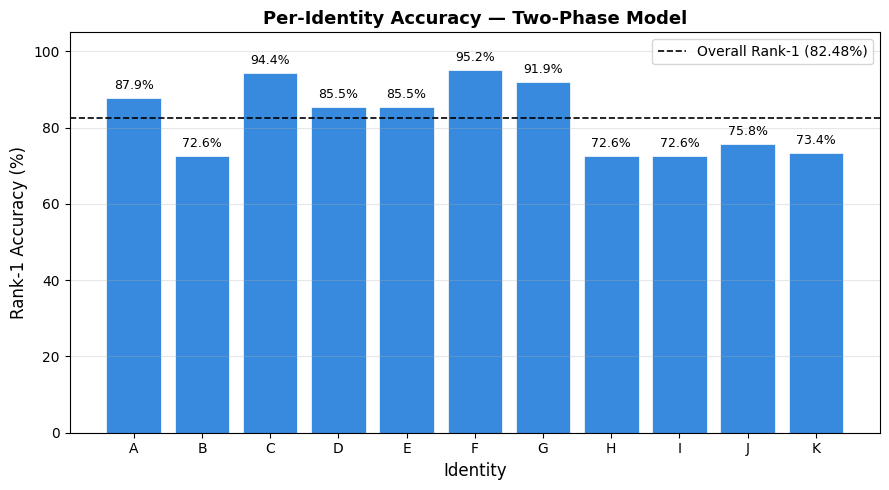


Top 10 worst failure cases:
True Predicted  Count  Error Rate (%)
   H         F     20           16.13
   I         F     17           13.71
   B         K     16           12.90
   K         B     13           10.48
   H         I     12            9.68
   I         C     11            8.87
   K         C     10            8.06
   B         F      8            6.45
   D         C      8            6.45
   E         C      7            5.65


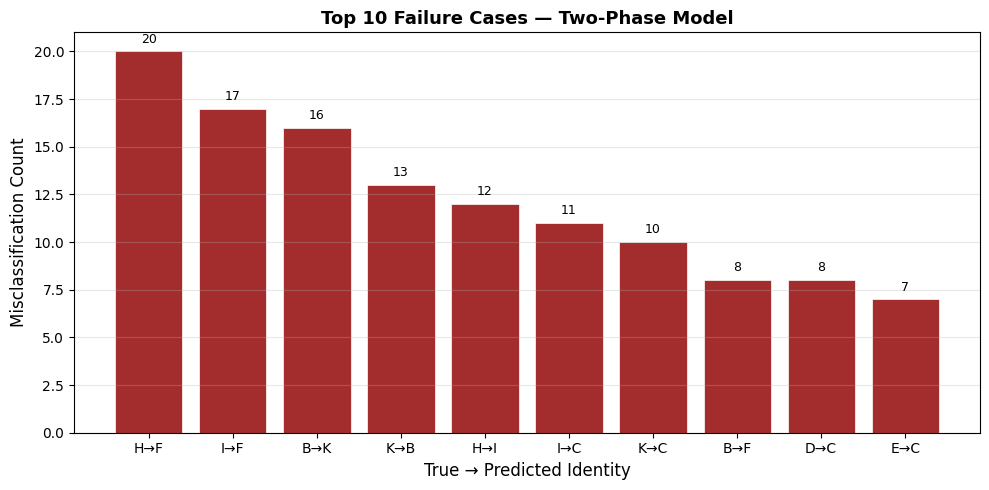

Saved both figures.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

cm = np.load('results/confusion_matrix.npy')
id_names = ['A','B','C','D','E','F','G','H','I','J','K']

# Calculating per-identity accuracy and error rate
per_id_acc = cm.diagonal() / cm.sum(axis=1) * 100
per_id_err = 100 - per_id_acc
overall_acc = cm.diagonal().sum() / cm.sum() * 100

df = pd.DataFrame({
    'Identity': id_names,
    'Accuracy (%)': per_id_acc.round(2),
    'Error Rate (%)': per_id_err.round(2),
    'Total Samples': cm.sum(axis=1)
})
print(df.to_string(index=False))
print(f'\nOverall Rank-1 (from confusion matrix): {overall_acc:.2f}%')

# Plotting per-identity accuracy
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#A32D2D' if a < 70 else '#378ADD' for a in per_id_acc]
bars = ax.bar(id_names, per_id_acc, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=overall_acc, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall Rank-1 ({overall_acc:.2f}%)')
ax.set_xlabel('Identity', fontsize=12)
ax.set_ylabel('Rank-1 Accuracy (%)', fontsize=12)
ax.set_title('Per-Identity Accuracy — Two-Phase Model', fontsize=13, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, per_id_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('results/analysis/per_identity_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()

# Identifying worst failure cases from the confusion matrix
# Find top confused pairs (off-diagonal)
confusion_pairs = []
for i in range(len(id_names)):
    for j in range(len(id_names)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'True': id_names[i],
                'Predicted': id_names[j],
                'Count': cm[i, j],
                'Error Rate (%)': round(cm[i, j] / cm[i].sum() * 100, 2)
            })

failures_df = pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False)
print('\nTop 10 worst failure cases:')
print(failures_df.head(10).to_string(index=False))

# Plot top 10 confusion pairs
top10 = failures_df.head(10)
top10_labels = [f"{r['True']}→{r['Predicted']}" for _, r in top10.iterrows()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top10_labels, top10['Count'], color='#A32D2D', edgecolor='white', linewidth=0.5)
ax.set_xlabel('True → Predicted Identity', fontsize=12)
ax.set_ylabel('Misclassification Count', fontsize=12)
ax.set_title('Top 10 Failure Cases — Two-Phase Model', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, count in zip(ax.patches, top10['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(count)), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('results/analysis/worst_failure_cases.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved both figures.')